In [ ]:
!pip install opencv-python-headless scikit-learn

In [ ]:
!pip install opencv-python-headless scikit-learn streamlit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 96.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 102.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.0 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('')

Mounted at /content/drive


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
from PIL import Image
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import streamlit as st

In [ ]:
input_folder = 'internship-510/split_img1'
output_csv = 'internship-510/severity_labels.csv'

In [ ]:
image_data = []
os.makedirs("classified_images", exist_ok=True)

for fname in os.listdir(input_folder):
    if fname.lower().endswith(('.jpg', '.png')):
        fpath = os.path.join(input_folder, fname)
        img = cv2.imread(fpath)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        _, thresh = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY)
        ratio = np.sum(thresh == 255) / (gray.shape[0] * gray.shape[1])

        if ratio < 0.01:
            label = "normal"
        elif ratio < 0.05:
            label = "minor"
        elif ratio < 0.15:
            label = "moderate"
        else:
            label = "severe"

        out_dir = f'classified_images/{label}'
        os.makedirs(out_dir, exist_ok=True)
        cv2.imwrite(os.path.join(out_dir, fname), img)

        image_data.append([fname, ratio, label])


In [ ]:
cv2.

In [ ]:
pd.DataFrame(image_data, columns=["filename", "hotspot_ratio", "label"]).to_csv(output_csv, index=False)

In [ ]:
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
img_size = (224, 224)
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

train_gen = train_datagen.flow_from_directory(
    'classified_images',
    target_size=img_size,
    batch_size=16,
    class_mode='categorical',
    subset='training')

val_gen = train_datagen.flow_from_directory(
    'classified_images',
    target_size=img_size,
    batch_size=16,
    class_mode='categorical',
    subset='validation')

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(4, activation='softmax')
])


Found 1061 images belonging to 4 classes.
Found 263 images belonging to 4 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=[early_stop]
)
model.save("severity_cnn_model.h5")

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


67/67 ━━━━━━━━━━━━━━━━━━━━ 113s 2s/step - accuracy: 0.4412 - loss: 3.6743 - val_accuracy: 0.6084 - val_loss: 0.7769
Epoch 2/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 105s 2s/step - accuracy: 0.6728 - loss: 0.7153 - val_accuracy: 0.8365 - val_loss: 0.5403
Epoch 3/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 105s 2s/step - accuracy: 0.8457 - loss: 0.4457 - val_accuracy: 0.8821 - val_loss: 0.3726
Epoch 4/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 106s 2s/step - accuracy: 0.8733 - loss: 0.3248 - val_accuracy: 0.8973 - val_loss: 0.3010
Epoch 5/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 105s 2s/step - accuracy: 0.9468 - loss: 0.1668 - val_accuracy: 0.9087 - val_loss: 0.2665
Epoch 6/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 106s 2s/step - accuracy: 0.9518 - loss: 0.1422 - val_accuracy: 0.9087 - val_loss: 0.2827
Epoch 7/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - accuracy: 0.9387 - loss: 0.1611 - val_accuracy: 0.9087 - val_loss: 0.3904
Epoch 8/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step - accuracy: 0.9783 - loss: 0.0699 - val_accuracy: 0.9278 - val_loss: 0.

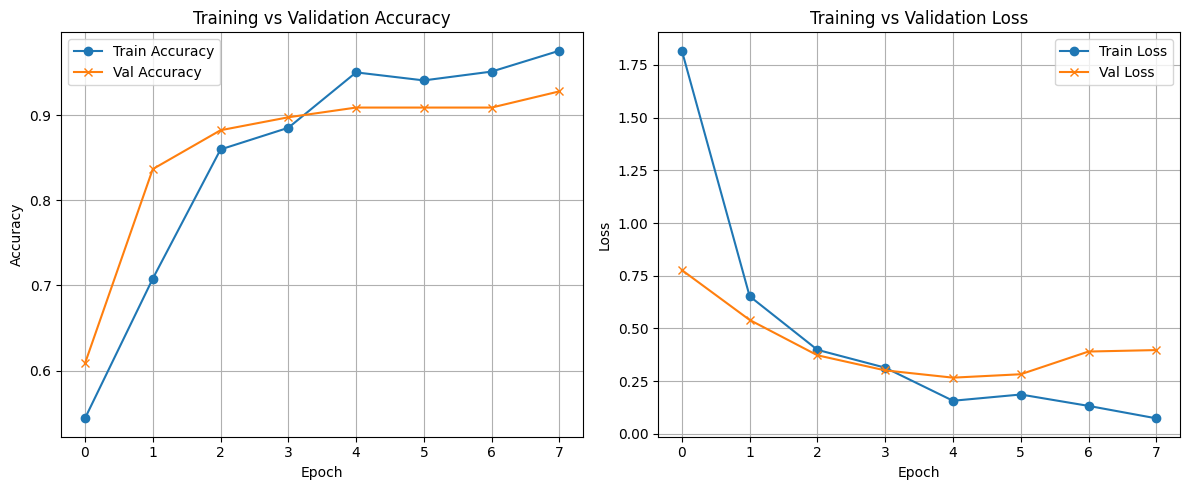

In [ ]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', marker='x')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss', marker='x')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
%%writefile app.py
import streamlit as st
from PIL import Image
import numpy as np
from tensorflow.keras.models import load_model
import warnings
warnings.filterwarnings("ignore")

model = load_model("severity_cnn_model.h5", compile=False)

class_labels = ["normal", "minor", "moderate", "severe"]

st.set_page_config(page_title="Hotspot Detection", layout="centered")
st.title("Solar Panel Hotspot Severity Classification")

uploaded_file = st.file_uploader("Upload a thermal image", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    image = Image.open(uploaded_file).convert("RGB")
    st.image(image, caption="Uploaded Image", use_container_width=True)
    st.write("Image uploaded successfully.")


    img_array = image.resize((224, 224))
    img_array = np.array(img_array) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    predicted_class = np.argmax(prediction)
    confidence = np.max(prediction)

    severity = class_labels[predicted_class]


    st.subheader(f"Predicted Severity: `{severity.upper()}`")
    st.text(f"Confidence: {confidence:.2%}")

    if severity == "normal":
        st.success("No significant hotspot detected.")
    elif severity == "minor":
        st.info("Minor hotspot detected.")
    elif severity == "moderate":
        st.warning("Moderate hotspot detected. Consider inspection.")
    else:
        st.error("Severe hotspot detected! Immediate action recommended.")

    print("Prediction result:", prediction)


Writing app.py


In [ ]:
!pip install pyngrok
from pyngrok import ngrok
import os

!pkill streamlit

NGROK_AUTH_TOKEN = "2yMhb8YLukVXjratImZdxgTqXM0_7SnnSYcqsKbHeAtUqiaK1"
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

streamlit_port = 8501

public_url = ngrok.connect(f"localhost:{streamlit_port}")
print(f"Streamlit app will be available at: {public_url}")
!streamlit run app.py &


Streamlit app will be available at: NgrokTunnel: "https://d875-34-86-38-126.ngrok-free.app" -> "http://localhost:8501"



  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.86.38.126:8501

2025-06-19 03:46:06.114704: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750304766.144554    7320 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750304766.153313    7320 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-19 03:46:11.986836: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Fail